# Chromatin Loops Analysis

This notebook analyzes chromatin loops to identify differential patterns between SZ and Healthy samples.

In [ ]:
import pandas as pdfrom scipy.spatial.distance import pdist, squareformfrom scipy.cluster.hierarchy import fclusterdataimport numpy as npfrom sklearn.cluster import DBSCANfrom os import listdirfrom tqdm import tqdmimport matplotlib.pyplot as pltfrom intervaltree import Interval, IntervalTreefrom collections import Counterfrom itertools import chainimport osimport globimport jsonimport timeimport seaborn as snsfrom mpl_toolkits.axes_grid1 import make_axes_locatableimport coolerimport bioframeimport cooltoolsfrom cooltools.lib.numutils import fill_diagfrom statsmodels.stats.multitest import multipletestsfrom os.path import isfile, join, basenameimport bioframe as bfimport concurrent.futuresfrom concurrent.futures import ThreadPoolExecutorfrom io import StringIOimport picklefrom concurrent.futures import ProcessPoolExecutor, as_completed, ThreadPoolExecutorimport warningsfrom typing import Unionfrom sklearn.preprocessing import StandardScalerfrom sklearn.decomposition import PCAimport plotly.express as pxfrom adjustText import adjust_textfrom dotenv import load_dotenvload_dotenv()import matplotlib as mpl
import pickle
import gseapy as gp
from gseapy import barplot, dotplot

# Chromatin Loops Analysis

This notebook analyzes chromatin loops to identify differential patterns between SZ and Healthy samples.

In [2]:
path_to_maps = os.getenv("PATH_TO_PROCESSED_MAPS")path_to_maps_expected = "../0.additional_data/expected_maps/"path_to_loops_clusters_data = "./loops_cooltools_data_noSexChromosomes/loops_clusters_data_15kb"save_name = "loops_SZ_vs_Healthy"pattern = "_noHeader"name_appender=''merged_all_clusters = pd.read_pickle(f"{path_to_loops_clusters_data}/{save_name}_calculated_clusters_all{name_appender}.pickle")

In [3]:
# check out 3.2.create_chromatin_loops_layouts notebookfeature_importance = pd.read_feather('./loops_data/feature_importance.feather')

In [8]:
maps2loops = json.load(open('./loops_data/maps2loops_mapping.json'))sources = merged_all_clusters.source.unique()maps = list(maps2loops.keys())maps.sort()maps = [i.split("/")[-1] for i in maps]sources = merged_all_clusters.source.unique()sources.sort()source2map = dict(zip(sources, maps))

In [9]:
maps_stored = {}for source in sources:    maps_stored[source] = {}    map_name = source2map[source]    print(source, map_name)    clr = cooler.Cooler(f'{path_to_maps}/{source2map[source]}::/resolutions/{15000}')    maps_stored[source]['clr'] = clr    reduced_maps2loops = source2map[source].split('.mcool', 0)[0]    maps_stored[source]['expected'] = pd.read_pickle(f'{path_to_maps_expected}/{reduced_maps2loops}_perChrArm.pickle')    

HC-2Mplus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed HC-2Mplus.sampled.drop_diag.1kb.mcool
HC-318plus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed HC-318plus.sampled.drop_diag.1kb.mcool
HC-3Mplus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed HC-3Mplus.sampled.drop_diag.1kb.mcool
HC-91plus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed HC-91plus.sampled.drop_diag.1kb.mcool
HC24plus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed HC24plus.sampled.drop_diag.1kb.mcool
HCM12plus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed HCM12plus.sampled.drop_diag.1kb.mcool
SZ-01plus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed SZ-01plus.sampled.drop_diag.1kb.mcool
SZ-03plus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed SZ-03plus.sampled.drop_diag.1kb.mcool
SZ08plus_20kb_co

In [10]:
def get_hg38_arms():    hg38_chromsizes = bioframe.fetch_chromsizes('hg38')    hg38_cens = bioframe.fetch_centromeres('hg38')    hg38_arms = bioframe.make_chromarms(hg38_chromsizes, hg38_cens)    return hg38_arms[hg38_arms.chrom!='chrM'].reset_index(drop=True)hg38_arms = get_hg38_arms() 

In [ ]:
df['group'] = df.source.apply(lambda x: "SZ" if "SZ" in x else "Healthy")samples_with_age = {'HC-2Mplus': 62,'HC-3Mplus': 36,'HC-91plus': 59,'HC24plus': 54,'HC-318plus': 58,'HCM12plus': 35,'SZ-01plus': 36,'SZ-03plus': 57,'SZ08plus': 56,'SZ10plus': 50,'SZ20plus': 37,'SZ6plus': 62}age_group = {}for label, age in samples_with_age.items():    if age <= 40:        age_group[label] = "Young"    elif 40 < age <= 57:        age_group[label] = "Adult"    else:        age_group[label] = "Adult"df['sample_name'] = df.source.apply(lambda x: x.split("_")[0])df['age_group'] = df['sample_name'].map(age_group)SZ_sources = df[df['group'] == 'SZ']['source'].unique().tolist()HC_sources = df[df['group'] == 'Healthy']['source'].unique().tolist()HC_adult_sources = df[(df['group'] == 'Healthy') & (df['age_group'] == 'Adult')]['source'].unique().tolist()HC_young_sources = df[(df['group'] == 'Healthy') & (df['age_group'] == 'Young')]['source'].unique().tolist()

In [128]:
def create_matrix_calculated(source, merged_all_clusters, predefine_clusters=False):    """    For a given source, computes the matrix for all clusters.    """    # Use predefined clusters if provided (should be a DataFrame)    if isinstance(predefine_clusters, pd.DataFrame):        clusters = predefine_clusters    else:        clusters = merged_all_clusters[merged_all_clusters['source'] == source]    flank_size = 13 * 15_000    stack = cooltools.pileup(        maps_stored[source]['clr'],        clusters,        view_df=hg38_arms,        expected_df=maps_stored[source]['expected'],        flank=flank_size,        nproc=8    )    assert stack.shape[0] == clusters.shape[0]    res = {}    for cluster, mat in zip(clusters['cluster'], stack):        res[cluster] = mat    return (source, res)# Parallel computation across sourcesdef parallel_cluster_matrices(merged_all_clusters, predefine_clusters=False, max_workers=14):    sources = merged_all_clusters['source'].unique()    clusters_results = {}    with concurrent.futures.ProcessPoolExecutor(max_workers=max_workers) as executor:        futures = []        for source in sources:            futures.append(                executor.submit(create_matrix_calculated, source, merged_all_clusters, predefine_clusters)            )        for f in concurrent.futures.as_completed(futures):            source, stack = f.result()            clusters_results[source] = stack    return clusters_resultsclusters_results = parallel_cluster_matrices(merged_all_clusters, predefine_clusters=False, max_workers=4)with open('./loops_data/clusters_results.pkl', 'wb') as f:    pickle.dump(clusters_results, f)

In [162]:
top=20 def calculate_average_for_loop(top, group1, group2, groups_names_ALL,                              filter_only_internal=False,                              n_threads=4):    """    Parameters:    - top: int, number of features to take from each end    - group1, group2: lists of sources    - groups_names_ALL: list of names, e.g. ['SZ', 'HC']    - feature_importance, merged_all_clusters, clusters_results: required global data or pass as parameters    - filter_only_internal: bool    - n_threads: int, for parallelization    """    sorted_feat = feature_importance.sort_values('Loading')    top_down = sorted_feat.head(top).Feature.tolist()    top_up   = sorted_feat.tail(top).Feature.tolist()    overall_mean_all = {}    for group, name_group in zip([group1, group2], groups_names_ALL):        loops_for_ALL_sources = {'up': [], 'down': []}                def process_source(source):            result = {}            for list_of_loops, name in zip([top_up, top_down], ['up', 'down']):                if filter_only_internal:                    filtered_list_of_loops = []                    for cluster in list_of_loops:                        m = merged_all_clusters                        calc_arr = m.loc[(m.source == source) & (m.cluster == cluster), 'calculation'].values                        if len(calc_arr) > 0 and "from_cluster" in calc_arr[0]:                            filtered_list_of_loops.append(cluster)                else:                    filtered_list_of_loops = list_of_loops                matched_matrices = [                    clusters_results[source][i]                    for i in clusters_results[source]                    if i in filtered_list_of_loops                ]                if matched_matrices:                    mean_matrix = np.nanmean(np.stack(matched_matrices), axis=0)                    result[name] = mean_matrix                else:                    result[name] = None            return result        with ThreadPoolExecutor(max_workers=n_threads) as executor:            results = list(executor.map(process_source, group))                for name in ['up', 'down']:            matrices = [res[name] for res in results if res[name] is not None]            if matrices:                loops_for_ALL_sources[name] = matrices            else:                loops_for_ALL_sources[name] = []        overall_mean = {}        for name in ['up', 'down']:            arr_list = loops_for_ALL_sources[name]            if arr_list:                overall_mean[name] = np.nanmean(np.stack(arr_list), axis=0)            else:                overall_mean[name] = None        overall_mean_all[name_group] = overall_mean    return overall_mean_all

In [163]:
def plot_average_loop(overall_mean_all, groups_names_ALL, mode, vmax=0.5):    group1_values = overall_mean_all[groups_names_ALL[0]][mode]    group2_values = overall_mean_all[groups_names_ALL[1]][mode]    data = np.log2((group1_values + 1e-6) / (group2_values + 1e-6))        plt.figure(figsize=(4, 4))    flank =  9 * 15_000    resolution = 15_000          ax = plt.gca()    im = ax.imshow(        data,        vmax=vmax,        vmin=-vmax,        cmap='coolwarm'    )        divider = make_axes_locatable(ax)    cax = divider.append_axes("right", size="5%", pad=0.05)    cbar = plt.colorbar(im, cax=cax)    cbar.set_label('log2 mean intensity(observed/expected)')        ticks_pixels = np.linspace(0, flank * 2 // resolution, 5)    ticks_kbp = ((ticks_pixels - ticks_pixels[-1] / 2) * resolution // 1000).astype(int)    ax.set_xticks(ticks_pixels)    ax.set_xticklabels(ticks_kbp)    ax.set_yticks(ticks_pixels)    ax.set_yticklabels(ticks_kbp)        ax.set_title(f'{(" : ").join(groups_names_ALL)}')    ax.set_xlabel('Relative position, Kb')    ax.set_ylabel('Relative position, Kb')    center_y = data.shape[0] // 2    center_x = data.shape[1] // 2    center_val = data[center_y, center_x]    ax.text(        0.03, 0.97,         f"center={center_val:.2f}",         ha='left', va='top', fontsize=10, color='black',         transform=ax.transAxes,         bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8)    )        plt.show()top_down = feature_importance.sort_values('Loading').head(top).Feature.tolist()top_up = feature_importance.sort_values('Loading').tail(top).Feature.tolist()

TOP: 20


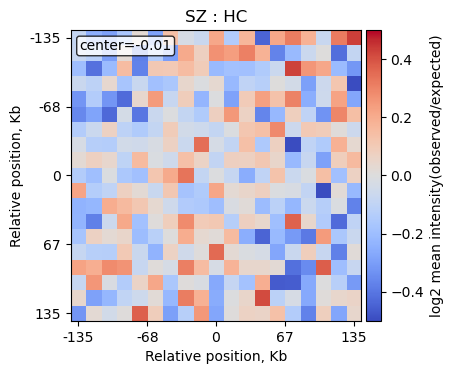

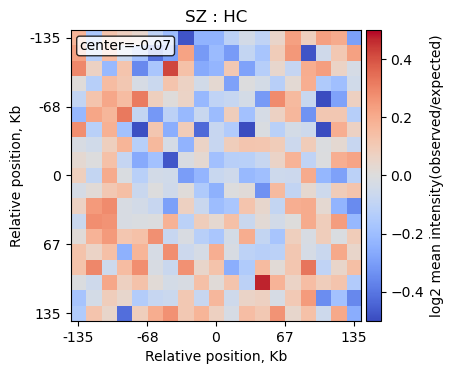

________________________________________________________________________________
TOP: 30


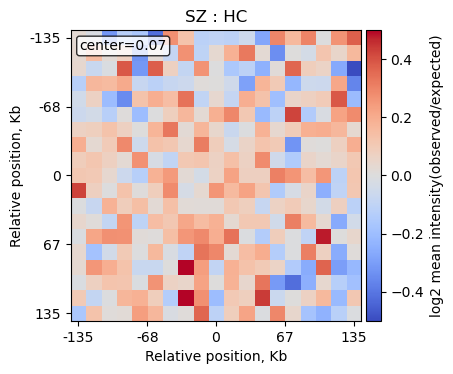

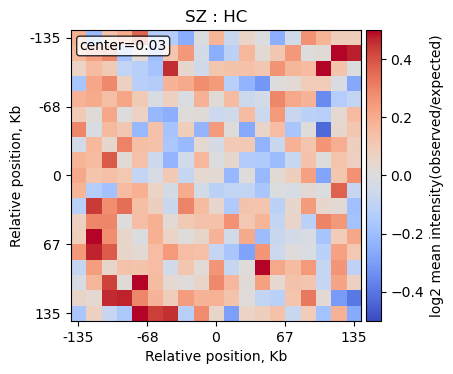

________________________________________________________________________________
TOP: 100


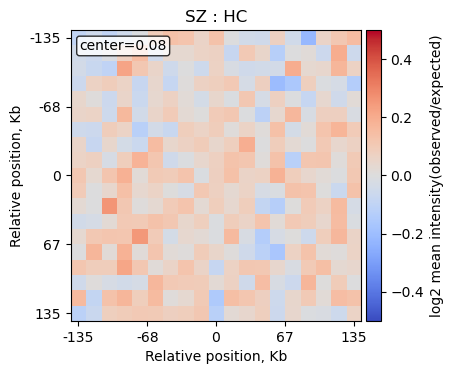

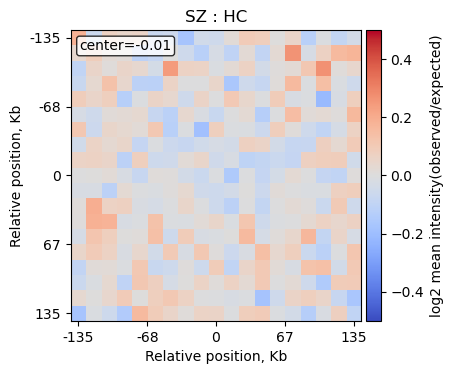

________________________________________________________________________________
TOP: 200


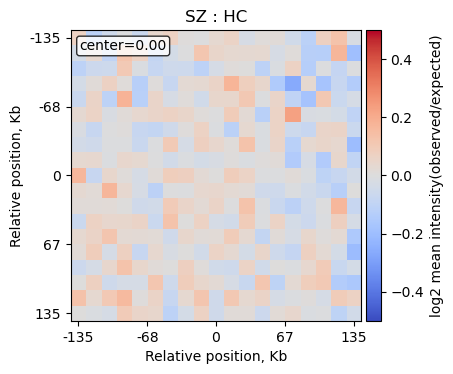

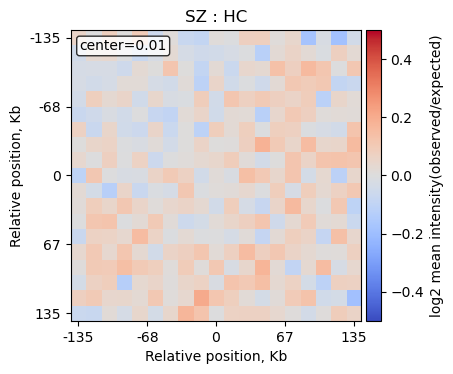

________________________________________________________________________________


In [166]:
for top in [20, 30, 100, 200]:    print(f"TOP: {top}")    group1 = SZ_sources    group2 = HC_sources    groups_names_ALL = ['SZ', 'HC']    overall_mean_all = calculate_average_for_loop(top, group1, group2, groups_names_ALL,filter_only_internal=True )        mode = 'down'    plot_average_loop(overall_mean_all, groups_names_ALL, mode, vmax=0.5)        mode = 'up'    plot_average_loop(overall_mean_all, groups_names_ALL, mode, vmax=0.5)    print('_'*80)

TOP: 20


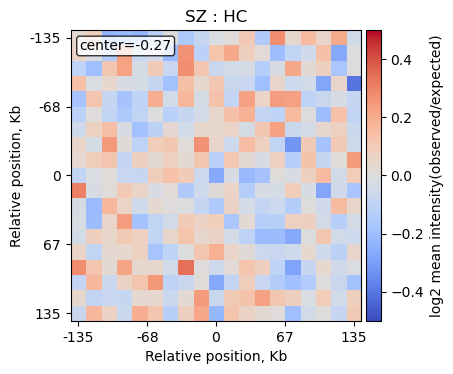

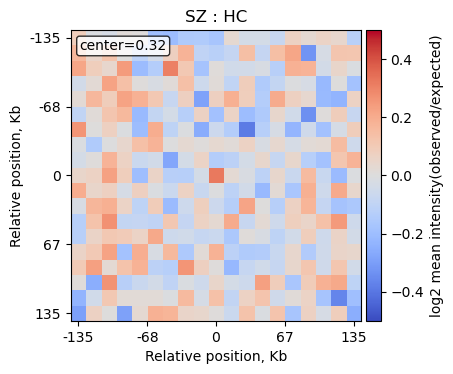

________________________________________________________________________________
TOP: 30


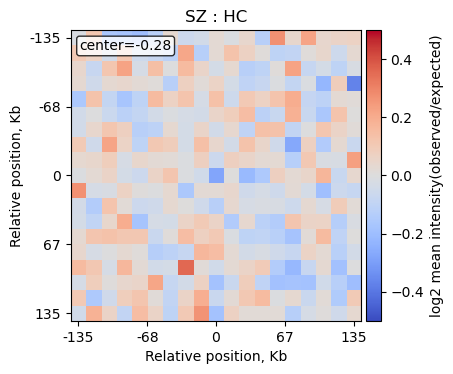

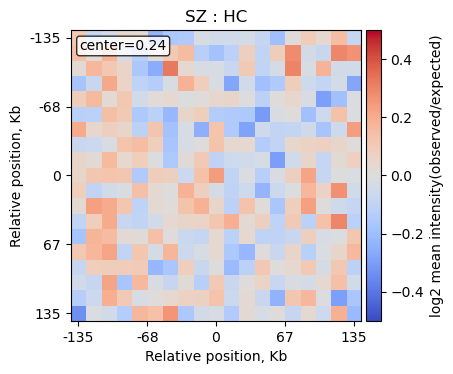

________________________________________________________________________________
TOP: 100


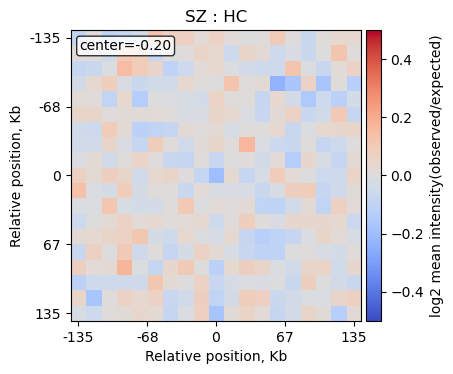

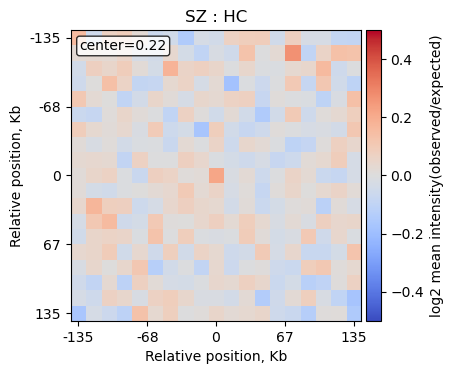

________________________________________________________________________________
TOP: 200


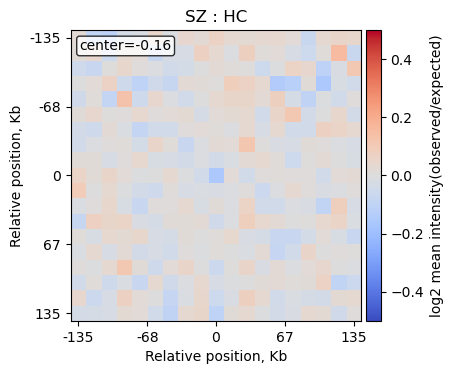

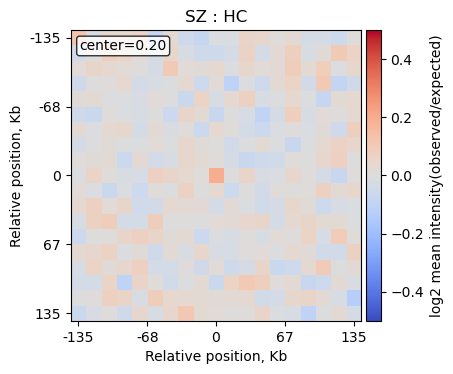

________________________________________________________________________________


In [148]:
for top in [20, 30, 100, 200]:    print(f"TOP: {top}")    group1 = SZ_sources    group2 = HC_sources    groups_names_ALL = ['SZ', 'HC']    overall_mean_all = calculate_average_for_loop(top, group1, group2, groups_names_ALL)        mode = 'down'    plot_average_loop(overall_mean_all, groups_names_ALL, mode, vmax=0.5)        mode = 'up'    plot_average_loop(overall_mean_all, groups_names_ALL, mode, vmax=0.5)    print('_'*80)

TOP: 20


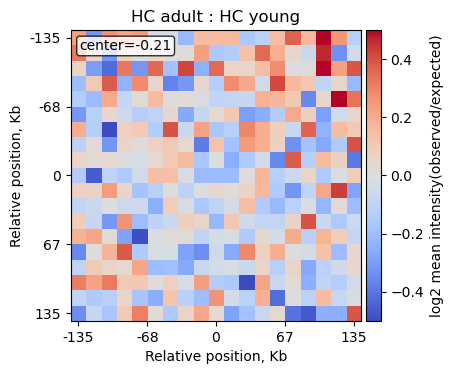

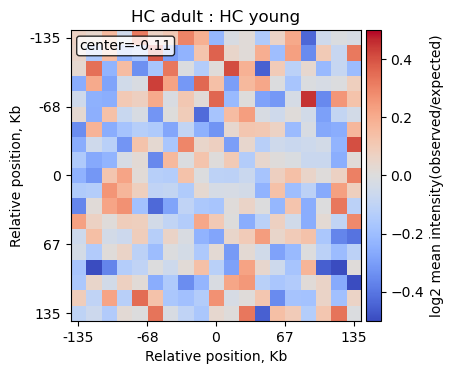

________________________________________________________________________________
TOP: 30


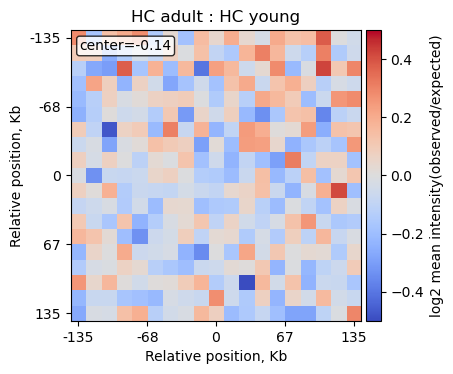

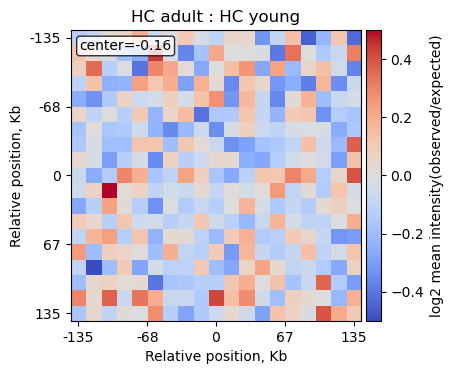

________________________________________________________________________________
TOP: 100


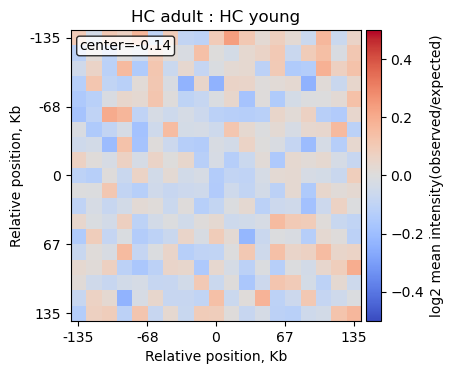

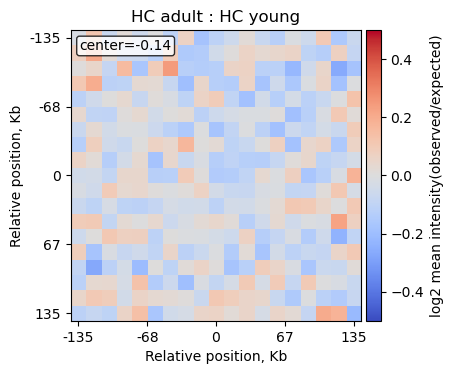

________________________________________________________________________________
TOP: 200


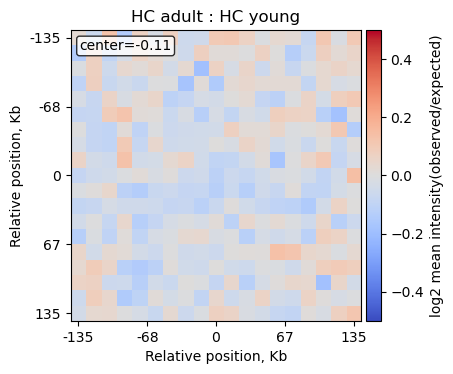

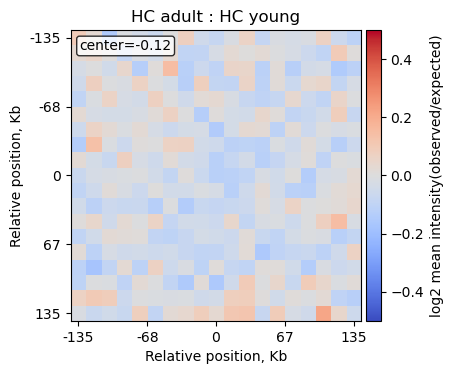

________________________________________________________________________________


In [147]:
for top in [20, 30, 100, 200]:    print(f"TOP: {top}")    group1 = HC_adult_sources    group2 = HC_young_sources    groups_names_ALL = ['HC adult', 'HC young']    overall_mean_all = calculate_average_for_loop(top, group1, group2, groups_names_ALL)        mode = 'down'    plot_average_loop(overall_mean_all, groups_names_ALL, mode, vmax=0.5)        mode = 'up'    plot_average_loop(overall_mean_all, groups_names_ALL, mode, vmax=0.5)    print('_'*80)

# GO annotation

In [57]:
def run_go_diff_loops_2lists(genes, background, add_pathways, name= None):    sns.set(style="whitegrid")    plt.rcParams["svg.fonttype"] = "none"    if name:        print(f"Dataset - {name}")    print(f"In gene_list - {len(genes)} genes, in the background - {len(background)}")    gene_set = ['GO_Biological_Process_2021',                'GO_Cellular_Component_2021',                'GO_Molecular_Function_2021']    if add_pathways:        gene_set+=['MSigDB_Hallmark_2020','KEGG_2021_Human', "WikiPathway_2023_Human"]    enr = gp.enrichr(gene_list=genes,                     background=background,                     gene_sets=gene_set,                     organism='Human',                     outdir=None,                     )    return enrdef get_dot_plot(enr: pd.DataFrame) -> None:    significant_results = enr.results.query('`Adjusted P-value` < 0.05')        if significant_results.shape[0] > 0:        for i, term in enumerate(significant_results.sort_values('Adjusted P-value').Term.tolist()):            print(f"{i + 1}. {term}")                term_count = significant_results.shape[0]        if term_count <= 4:            height, width = 3, 5        elif 4 < term_count < 9:            height, width = 5, 6        elif 9 <= term_count < 13:            height, width = 7, 8        else:            height, width = 8, 11                ax = dotplot(            significant_results,            column="Adjusted P-value",            x='Gene_set',              size=3,            top_term=15,            figsize=(width, height),            title="GO",            xticklabels_rot=45,              show_ring=True,             marker='o',        )        plt.show()    else:        print('No enriched terms at Adjusted P-value < 0.05')def get_genes_from_gsea(enr):    genes = []    for i in enr.results[enr.results['Adjusted P-value'] <=0.05].Genes.tolist():        for e in i.split(';'):            genes.append(e.strip())    genes = list(set(genes))    print(f"There are {len(genes)} genes")    return genesdef prettify_dotplot(enr_results, save_name):    # Filter significant results    df = enr_results.query('`Adjusted P-value` < 0.05').copy()    if df.empty:        print("No significant terms at FDR < 0.05")        return        df = df.replace([np.inf, -np.inf], np.nan)    df['Combined Score'] = df['Combined Score'].fillna(df['Combined Score'].max())    df['Odds Ratio'] = df['Odds Ratio'].replace(np.nan, df['Odds Ratio'].max())        df['Gene Count'] = df['Genes'].str.count(';') + 1    plt.figure(figsize=(7, 2 + 0.5*len(df)))    sns.set(style="whitegrid")    plt.rcParams["svg.fonttype"] = "none"    df = df.sort_values('Adjusted P-value', ascending=False)    scatter = plt.scatter(    y=df['Term'],        x=df['Odds Ratio'],        s=df['Gene Count']*40,        c=df['Adjusted P-value'],   # color is raw adjusted p-value        cmap="viridis",             # default: small=dark, large=yellow        alpha=0.85,        edgecolor='k'    )    plt.colorbar(scatter, label='Adjusted P-value')    plt.xlabel("Odds Ratio", fontsize=13)    plt.ylabel("", fontsize=13)    plt.yticks(fontsize=10)    plt.xticks(fontsize=10)    plt.title("Top Enriched GO Terms", fontsize=15, weight='bold', pad=20)    sns.despine(left=True, bottom=True)        plt.subplots_adjust(top=0.96, bottom=0.13)    plt.tight_layout(rect=[0, 0.02, 1, 0.98])  # <-- Add this line!    plt.savefig(f'./feature_importance_visualizations/go_enrichment_{save_name}.svg',                 bbox_inches='tight', pad_inches=0.2)    plt.show()

In [19]:
df = merged_all_clusters_promoter_data[['fi_quantile_30', 'cluster', 'gene_name']].drop_duplicates().dropna()top_promoters = df[df.fi_quantile_30.isin([29])].gene_name.unique().tolist()down_promoters = df[df.fi_quantile_30.isin([0])].gene_name.unique().tolist()all_promoters_in_loops = df.gene_name.unique().tolist()

In gene_list - 183 genes, in the background - 4410
1. regulation of axonogenesis (GO:0050770)
2. central nervous system neuron development (GO:0021954)


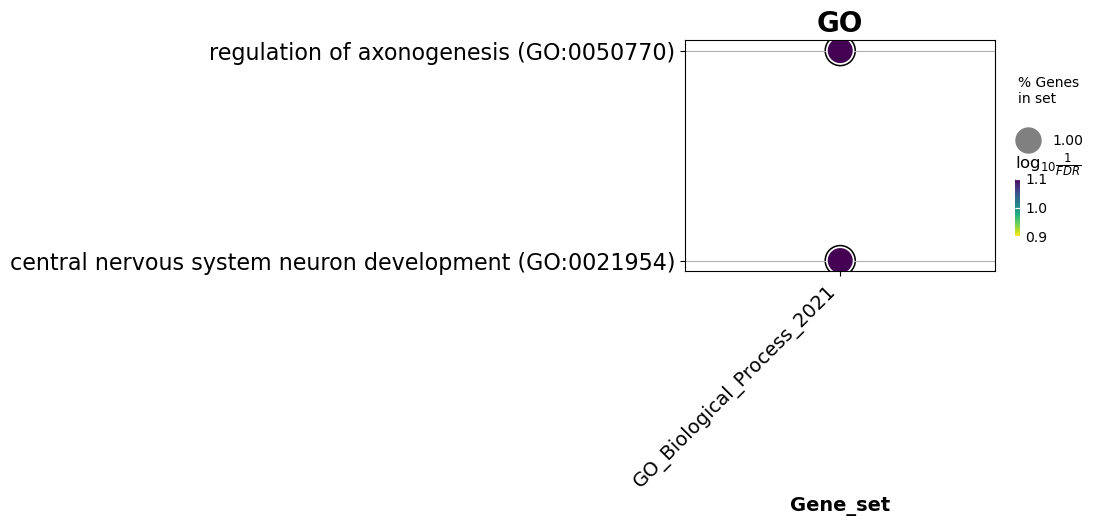

In [20]:
add_pathways=Trueenr_top_promoters = run_go_diff_loops_2lists(top_promoters, all_promoters_in_loops, add_pathways)get_dot_plot(enr_top_promoters)

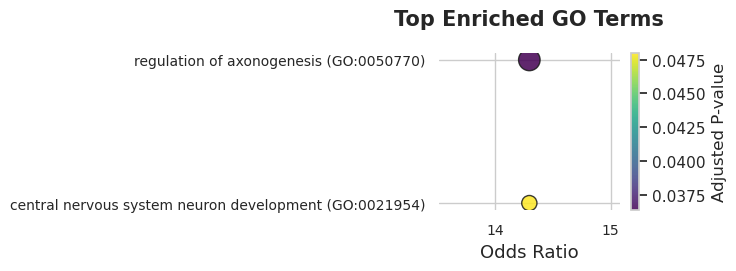

In [58]:
prettify_dotplot(enr_top_promoters.results.sort_values('Adjusted P-value', ascending=False), save_name="up_sz_loops")

In [46]:
enr_top_promoters.results.sort_values('Adjusted P-value', ascending=True)

,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,regulation of axonogenesis (GO:0050770),0.000027,0.036339,0,0,14.294915,150.579570,EPHA4;NTRK2;PTEN;LRP4;SLIT2;ARHGAP35
1,GO_Biological_Process_2021,central nervous system neuron development (GO:...,0.000070,0.048003,0,0,inf,inf,NTRK2;PTEN;ARHGAP35
2,GO_Biological_Process_2021,nucleotide-binding oligomerization domain cont...,0.000176,0.080189,0,0,23.592179,203.923064,CYLD;LACC1;TRAF6;RELA
3,GO_Biological_Process_2021,protein monoubiquitination (GO:0006513),0.000495,0.155875,0,0,15.720670,119.646280,CTR9;RNF40;RAD18;RAG1
4,GO_Biological_Process_2021,negative regulation of synaptic transmission (...,0.000661,0.155875,0,0,35.208333,257.789229,ATAD1;GRIK3;PTEN
...,...,...,...,...,...,...,...,...,...
1504,GO_Cellular_Component_2021,intracellular organelle lumen (GO:0070013),0.976382,0.983357,0,0,0.442964,0.010587,SUCLA2;PDE2A;ESD;ISCU
1362,GO_Biological_Process_2021,neutrophil activation involved in immune respo...,0.987937,0.988661,0,0,0.222204,0.002697,SYNGR1
1363,GO_Biological_Process_2021,neutrophil degranulation (GO:0043312),0.987937,0.988661,0,0,0.222204,0.002697,SYNGR1
1364,GO_Biological_Process_2021,neutrophil mediated immunity (GO:0002446),0.988940,0.988940,0,0,0.217825,0.002423,SYNGR1


In [724]:
get_genes_from_gsea(enr_top_promoters.sort_values('Adjusted P-value', ascending=True))

,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,regulation of axonogenesis (GO:0050770),0.000027,0.036339,0,0,14.294915,150.579570,EPHA4;NTRK2;PTEN;LRP4;SLIT2;ARHGAP35
1,GO_Biological_Process_2021,central nervous system neuron development (GO:...,0.000070,0.048003,0,0,inf,inf,NTRK2;PTEN;ARHGAP35
2,GO_Biological_Process_2021,nucleotide-binding oligomerization domain cont...,0.000176,0.080189,0,0,23.592179,203.923064,CYLD;LACC1;TRAF6;RELA
3,GO_Biological_Process_2021,protein monoubiquitination (GO:0006513),0.000495,0.155875,0,0,15.720670,119.646280,CTR9;RNF40;RAD18;RAG1
4,GO_Biological_Process_2021,negative regulation of synaptic transmission (...,0.000661,0.155875,0,0,35.208333,257.789229,ATAD1;GRIK3;PTEN
...,...,...,...,...,...,...,...,...,...
2262,WikiPathway_2023_Human,Alzheimer 39 S Disease And miRNA Effects WP2059,0.807735,0.815949,0,0,0.656196,0.140112,PSMC1;RELA
2263,WikiPathway_2023_Human,Alzheimer 39 S Disease WP5124,0.807735,0.815949,0,0,0.656196,0.140112,PSMC1;RELA
2264,WikiPathway_2023_Human,Sudden Infant Death Syndrome SIDS Susceptibili...,0.825488,0.831066,0,0,0.575137,0.110300,NTRK2
2265,WikiPathway_2023_Human,Calcium Regulation In Cardiac Cells WP536,0.891063,0.894063,0,0,0.449903,0.051892,ADCY7


In [725]:
get_genes_from_gsea(enr_top_promoters)

There are 6 genes


['PTEN', 'ARHGAP35', 'LRP4', 'EPHA4', 'SLIT2', 'NTRK2']

In gene_list - 217 genes, in the background - 4410
1. endoplasmic reticulum lumen (GO:0005788)


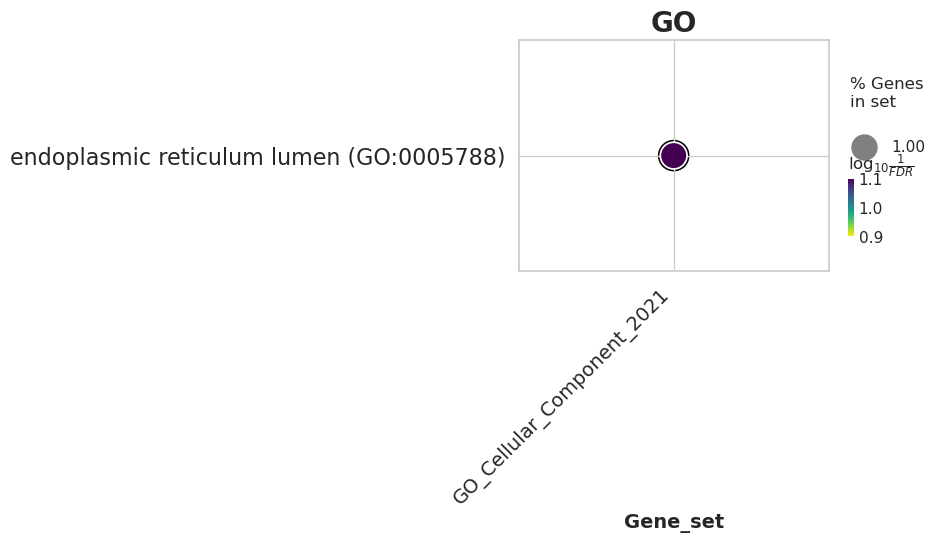

In [60]:
enr_down_promoters = run_go_diff_loops_2lists(down_promoters, all_promoters_in_loops, add_pathways)get_dot_plot(enr_down_promoters)